# Task 2: Face Mask Detection using Transfer Learning

## Overview
Develop Transfer Learning models to detect whether humans are wearing face masks. This task involves:
- Loading and preprocessing image datasets
- Preparing training, validation, and test data with defined image dimensions
- Developing Transfer Learning models using pre-trained networks
- Evaluating and comparing model performance

## Dataset
- **File**: `data/Face_mask_detection.zip`
- **Classes**: With Mask, Without Mask

## Rubric Coverage
1. Data Preprocessing (8 pts)
2. Building the Model (8 pts)
3. Model Training with Hyperparameter Experimentation (8 pts)
4. Model Evaluation (8 pts)
5. Visualization and Reporting (8 pts)

---
# 1. Imports and Setup

In [1]:
# Standard imports
import os
import zipfile
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Deep Learning imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, 
                                     GlobalAveragePooling2D, Flatten, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, MobileNetV2, ResNet50

# Sklearn imports
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## When using Colab, Download any missing data files from Google Drive to /content/data

In [3]:
import os
import gdown
from textwrap import dedent

# Unit 4 Incremental Capstone Google Drive Data Files
FOLDER_ID = "1WJUxYQNtlGy1q5EQjIjRuo2SFxVW9ivC?usp=sharing"

# Files expected to be found in Google drive data folder
EXPECTED_FILES = ['Churn_Modeling.csv','DENTAL_1.NPZ','Face_mask_detection.zip','GrammarandProductReviews.xlsx']

# colab data direcotry
DATA_DIR = '/content/data'

def download_data_files():
    print("Downloading from Drive folder...")
    url = f'https://drive.google.com/drive/folders/{FOLDER_ID}'
    gdown.download_folder(url, output=DATA_DIR, quiet=False, use_cookies=False)

def ensure_data_available():
    """Download only missing files from Google Drive folder."""
    os.makedirs(DATA_DIR, exist_ok=True)

    local_files = set(os.listdir(DATA_DIR)) if os.listdir(DATA_DIR) else set()
    missing = set(EXPECTED_FILES) - local_files

    print(f"Local files: {local_files}")
    print(f"Expected files: {EXPECTED_FILES}")

    if missing:
        print(f"Missing files: {missing}")
        download_data_files()
    else:
        print(f"✓ All files already present")

    # Verify all files are now available
    local_files = set(os.listdir(DATA_DIR))
    still_missing = set(EXPECTED_FILES) - local_files

    if still_missing:
        error_msg = dedent(f"""
            Failed to download all required files from Google Drive folder {FOLDER_ID}!
            - Local files: {local_files}
            - Expected files: {EXPECTED_FILES}
            - Failed to download: {still_missing}
        """)
        raise FileNotFoundError(error_msg)

    print(f"\nFiles in {DATA_DIR}:")
    for f in sorted(os.listdir(DATA_DIR)):
        size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024 * 1024)
        print(f"  {f}: {size_mb:.1f} MB")

def is_colab():
    return 'COLAB_RELEASE_TAG' in os.environ

# def is_colab():
#     try:
#         from IPython import get_ipython
#         return 'google.colab' in str(get_ipython())
#     except:
#         return False

# def is_colab():
#     return os.path.exists('/content') and os.path.exists('/usr/local/lib/python3')

if is_colab():
    DATA_DIR = '/content/data'
    # Download from Drive if needed
    !pip install -q gdown
    print(f"Running in Google Colab, downloading to {DATA_DIR} from Google Drive if needed...")
    ensure_data_available()
else:
    DATA_DIR = './data'  # Local path
    print(f"Running locally; skipping download step, using local files from {DATA_DIR}")



Running in Google Colab, downloading to /content/data from Google Drive if needed...
Local files: {'Face_mask_detection.zip', 'DENTAL_1.NPZ', 'Churn_Modeling.csv', 'GrammarandProductReviews.xlsx'}
Expected files: ['Churn_Modeling.csv', 'DENTAL_1.NPZ', 'Face_mask_detection.zip', 'GrammarandProductReviews.xlsx']
✓ All files already present

Files in /content/data:
  Churn_Modeling.csv: 0.7 MB
  DENTAL_1.NPZ: 174.0 MB
  Face_mask_detection.zip: 163.5 MB
  GrammarandProductReviews.xlsx: 2.1 MB


---
# 2. Data Preprocessing (Rubric Task 1: 8 pts)

**Objectives:**
- Extract the zip file
- Explore the dataset structure
- Resize images to consistent dimensions (224x224)
- Normalize pixel values [0, 1]
- Create training, validation, and test splits
- Apply data augmentation

## 2.1 Extract and Explore Dataset

In [4]:
# Extract the zip file
zip_path = f'{DATA_DIR}/Face_mask_detection.zip'
#extract_path = 'data/Face_mask_detection'
extract_path = f'{DATA_DIR}/data'

if not os.path.exists(extract_path):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('data/')
    print("Extraction complete!")
else:
    print(f"Dataset already extracted at {extract_path}")

# List contents
print("\nDataset structure:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # Only show first 2 levels
        subindent = ' ' * 2 * (level + 1)
        for d in dirs:
            print(f"{subindent}{d}/")

Extraction complete!

Dataset structure:
data/
  without_mask/
  with_mask/
  without_mask/
  with_mask/


In [5]:
# Find the actual data directory structure
# The zip might have different structures, let's find it
def find_image_dirs(base_path):
    """Find directories containing images."""
    image_dirs = []
    for root, dirs, files in os.walk(base_path):
        # Check if this directory contains images
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            image_dirs.append((root, len(image_files)))
    return image_dirs

image_dirs = find_image_dirs(extract_path)
print("Directories containing images:")
for dir_path, count in image_dirs:
    print(f"  {dir_path}: {count} images")

Directories containing images:
  /content/data/data/without_mask: 3828 images
  /content/data/data/with_mask: 3725 images


In [6]:
# Set up data directories (adjust based on actual structure)
# Common structures: train/test or with_mask/without_mask

# Try to identify the structure
base_data_dir = extract_path

# Look for train/test or direct class folders
subdirs = os.listdir(base_data_dir)
print(f"Contents of {base_data_dir}: {subdirs}")

# Check if there's a nested structure
for subdir in subdirs:
    subdir_path = os.path.join(base_data_dir, subdir)
    if os.path.isdir(subdir_path):
        contents = os.listdir(subdir_path)
        print(f"  {subdir}/: {contents[:5]}{'...' if len(contents) > 5 else ''}")

Contents of /content/data/data: ['without_mask', 'with_mask']
  without_mask/: ['without_mask_3745.jpg', 'without_mask_1192.jpg', 'without_mask_3294.jpg', 'without_mask_2190.jpg', 'without_mask_1729.jpg']...
  with_mask/: ['with_mask_180.jpg', 'with_mask_3300.jpg', 'with_mask_1844.jpg', 'with_mask_42.jpg', 'with_mask_2584.jpg']...


In [7]:
# Define image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 32

print("IMAGE PREPROCESSING PARAMETERS")
print("="*60)
print(f"Image Height: {IMG_HEIGHT}")
print(f"Image Width: {IMG_WIDTH}")
print(f"Batch Size: {BATCH_SIZE}")

IMAGE PREPROCESSING PARAMETERS
Image Height: 224
Image Width: 224
Batch Size: 32


## 2.2 Create Data Generators with Augmentation

In [8]:
# Find the correct data directory
# Look for common patterns
possible_paths = [
    os.path.join(extract_path, 'train'),
    os.path.join(extract_path, 'Train'),
    os.path.join(extract_path, 'data', 'train'),
    extract_path
]

train_dir = None
test_dir = None

for path in possible_paths:
    if os.path.exists(path):
        # Check if it has class subdirectories
        subdirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
        if any('mask' in d.lower() for d in subdirs):
            train_dir = path
            print(f"Found data directory: {train_dir}")
            print(f"Classes: {subdirs}")
            break

# Also check for test directory
test_paths = [
    os.path.join(extract_path, 'test'),
    os.path.join(extract_path, 'Test'),
    os.path.join(extract_path, 'data', 'test'),
]

for path in test_paths:
    if os.path.exists(path):
        test_dir = path
        print(f"Found test directory: {test_dir}")
        break

if train_dir is None:
    print("Could not find standard directory structure.")
    print("Please check the extracted contents and set train_dir manually.")

Found data directory: /content/data/data
Classes: ['without_mask', 'with_mask']


In [9]:
# Create ImageDataGenerators with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values to [0, 1]
    rotation_range=20,           # Random rotation
    width_shift_range=0.2,       # Horizontal shift
    height_shift_range=0.2,      # Vertical shift
    shear_range=0.2,             # Shear transformation
    zoom_range=0.2,              # Random zoom
    horizontal_flip=True,        # Horizontal flip
    fill_mode='nearest',
    validation_split=0.2         # 20% for validation
)

# Test/validation data generator (only rescaling, no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

print("DATA AUGMENTATION CONFIGURATION")
print("="*60)
print("""
Training Augmentation:
  - Rescale: 1/255 (normalize to [0,1])
  - Rotation: +/- 20 degrees
  - Width/Height Shift: 20%
  - Shear Range: 0.2
  - Zoom Range: 0.2
  - Horizontal Flip: Yes
  - Validation Split: 20%
""")

DATA AUGMENTATION CONFIGURATION

Training Augmentation:
  - Rescale: 1/255 (normalize to [0,1])
  - Rotation: +/- 20 degrees
  - Width/Height Shift: 20%
  - Shear Range: 0.2
  - Zoom Range: 0.2
  - Horizontal Flip: Yes
  - Validation Split: 20%



In [10]:
# Create data generators
# Use the training directory with validation split

if train_dir:
    # Training generator
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='training',
        shuffle=True
    )
    
    # Validation generator
    validation_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='validation',
        shuffle=False
    )
    
    # Test generator (if test directory exists)
    if test_dir:
        test_generator = test_datagen.flow_from_directory(
            test_dir,
            target_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            class_mode='binary',
            shuffle=False
        )
    else:
        # Use validation as test
        test_generator = validation_generator
        print("Note: Using validation data as test data")
    
    print(f"\nClass indices: {train_generator.class_indices}")
    print(f"Training samples: {train_generator.samples}")
    print(f"Validation samples: {validation_generator.samples}")

Note: Using validation data as test data

Class indices: {'with_mask': 0, 'without_mask': 1}
Training samples: 6043
Validation samples: 1510


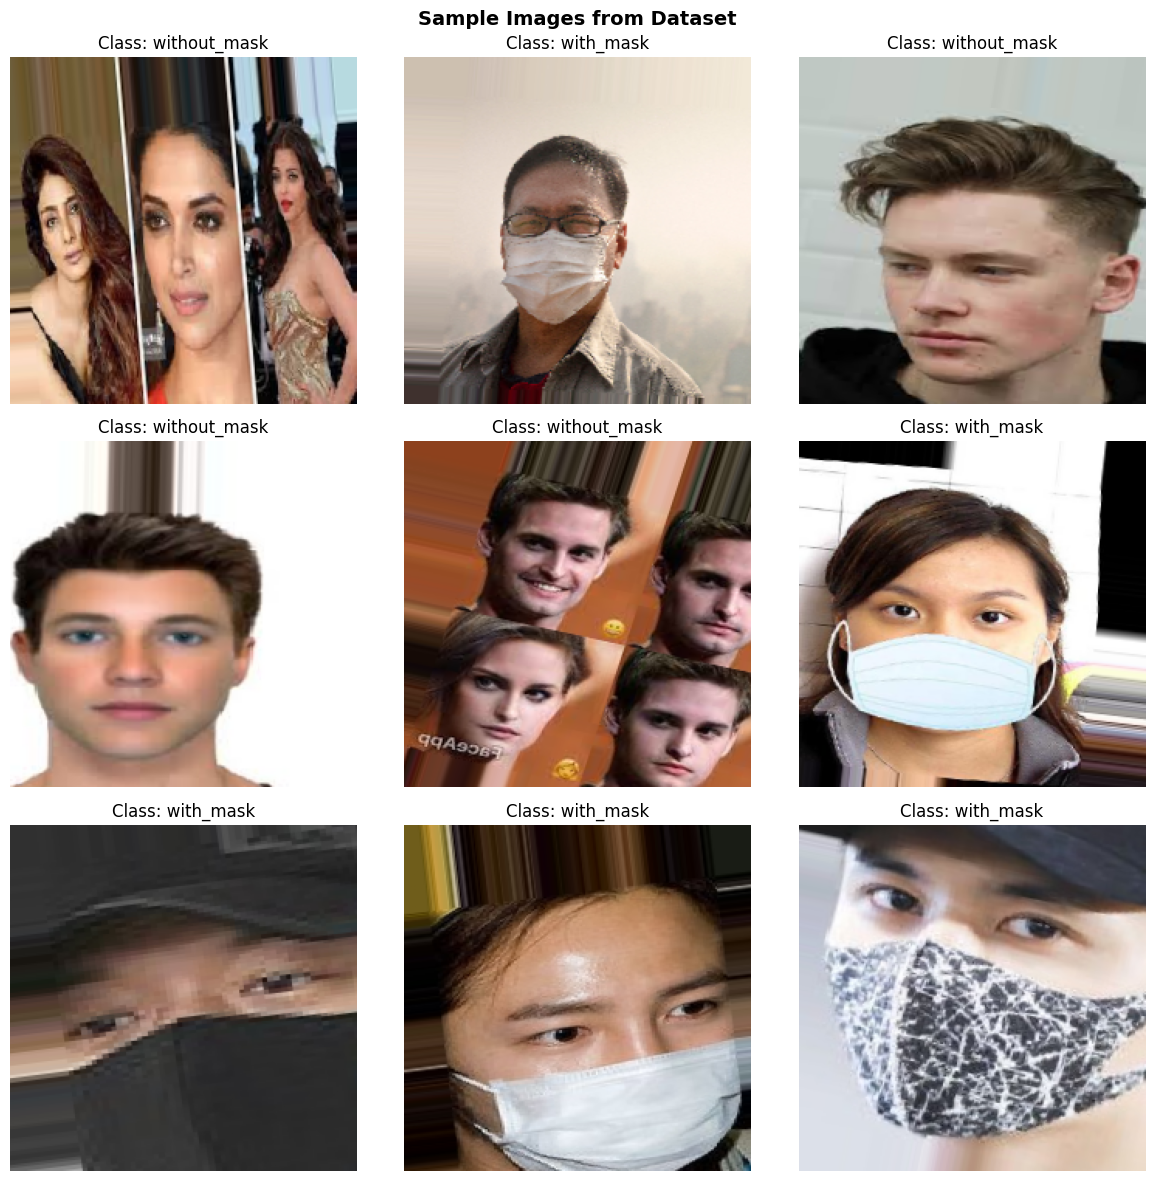

In [11]:
# Visualize sample images from dataset
def visualize_samples(generator, n_samples=9):
    """Visualize sample images from generator."""
    class_names = list(generator.class_indices.keys())
    
    # Get a batch
    images, labels = next(generator)
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i])
            label_idx = int(labels[i])
            ax.set_title(f'Class: {class_names[label_idx]}', fontsize=12)
            ax.axis('off')
    
    plt.suptitle('Sample Images from Dataset', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

if train_dir:
    visualize_samples(train_generator)

## 2.3 Preprocessing Summary

**Data Preprocessing Complete:**
- Extracted zip file and explored structure
- Images resized to 224x224 pixels
- Pixel values normalized to [0, 1]
- Data augmentation applied (rotation, shift, flip, zoom)
- Train/Validation split: 80%/20%
- Class: Binary (With Mask / Without Mask)

---
# 3. Building Transfer Learning Models (Rubric Task 2: 8 pts)

**Models to build:**
1. VGG16 (pre-trained on ImageNet)
2. MobileNetV2 (lightweight, efficient)

**Architecture components:**
- Pre-trained base (frozen initially)
- GlobalAveragePooling2D
- Dense layers with Dropout
- Softmax/Sigmoid output

In [12]:
def build_transfer_model(base_model_name='VGG16', input_shape=(224, 224, 3), 
                         learning_rate=0.001, fine_tune=False):
    """
    Build a Transfer Learning model for binary classification.
    
    Parameters:
    - base_model_name: 'VGG16', 'MobileNetV2', or 'ResNet50'
    - input_shape: Input image shape
    - learning_rate: Learning rate for optimizer
    - fine_tune: Whether to unfreeze some base layers
    
    Returns:
    - Compiled Keras model
    """
    
    # Load pre-trained base model
    if base_model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'MobileNetV2':
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError(f"Unknown model: {base_model_name}")
    
    # Freeze base model layers
    base_model.trainable = False
    
    # Build the model
    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs, name=f'{base_model_name}_TransferLearning')
    
    # Optionally fine-tune some layers
    if fine_tune:
        # Unfreeze the last few layers of base model
        base_model.trainable = True
        for layer in base_model.layers[:-20]:  # Freeze all but last 20 layers
            layer.trainable = False
    
    # Compile
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model, base_model

In [13]:
# Build VGG16 model
print("BUILDING VGG16 TRANSFER LEARNING MODEL")
print("="*60)

vgg16_model, vgg16_base = build_transfer_model(
    base_model_name='VGG16',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    learning_rate=0.001
)

vgg16_model.summary()

 Non-trainable params: 14,715,200 (56.13 MB)

In [14]:
# Build MobileNetV2 model
print("\nBUILDING MobileNetV2 TRANSFER LEARNING MODEL")
print("="*60)

mobilenet_model, mobilenet_base = build_transfer_model(
    base_model_name='MobileNetV2',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    learning_rate=0.001
)

mobilenet_model.summary()

 Non-trainable params: 2,258,496 (8.62 MB)

In [15]:
# Model architecture explanation
print("TRANSFER LEARNING ARCHITECTURE DESIGN")
print("="*60)
print("""
1. BASE MODEL (Pre-trained on ImageNet):
   - VGG16: Classic architecture, 16 layers, larger model
   - MobileNetV2: Efficient, lightweight, good for mobile deployment
   - Weights frozen initially (feature extraction mode)

2. CUSTOM CLASSIFICATION HEAD:
   - GlobalAveragePooling2D: Reduces spatial dimensions
   - Dense(256) + ReLU: Feature transformation
   - BatchNormalization: Stabilizes training
   - Dropout(0.5): Prevents overfitting
   - Dense(128) + ReLU: Further feature learning
   - Dropout(0.3): Additional regularization
   - Dense(1) + Sigmoid: Binary classification output

3. REGULARIZATION TECHNIQUES:
   - Dropout layers (0.5, 0.3)
   - BatchNormalization
   - Data augmentation (applied during training)
""")

TRANSFER LEARNING ARCHITECTURE DESIGN

1. BASE MODEL (Pre-trained on ImageNet):
   - VGG16: Classic architecture, 16 layers, larger model
   - MobileNetV2: Efficient, lightweight, good for mobile deployment
   - Weights frozen initially (feature extraction mode)

2. CUSTOM CLASSIFICATION HEAD:
   - GlobalAveragePooling2D: Reduces spatial dimensions
   - Dense(256) + ReLU: Feature transformation
   - BatchNormalization: Stabilizes training
   - Dropout(0.5): Prevents overfitting
   - Dense(128) + ReLU: Further feature learning
   - Dropout(0.3): Additional regularization
   - Dense(1) + Sigmoid: Binary classification output

3. REGULARIZATION TECHNIQUES:
   - Dropout layers (0.5, 0.3)
   - BatchNormalization
   - Data augmentation (applied during training)



---
# 4. Model Training with Hyperparameter Experimentation (Rubric Task 3: 8 pts)

**Experiments:**
1. Compare VGG16 vs MobileNetV2
2. Different learning rates
3. Fine-tuning vs feature extraction

In [16]:
# Define callbacks
def get_callbacks(model_name):
    """Return callbacks for training."""
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]
    return callbacks

In [17]:
# Calculate steps
if train_dir:
    steps_per_epoch = train_generator.samples // BATCH_SIZE
    validation_steps = validation_generator.samples // BATCH_SIZE
    
    print(f"Steps per epoch: {steps_per_epoch}")
    print(f"Validation steps: {validation_steps}")

Steps per epoch: 188
Validation steps: 47


In [18]:
# Train VGG16 model
print("TRAINING VGG16 MODEL")
print("="*60)

EPOCHS = 20

if train_dir:
    vgg16_history = vgg16_model.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS,
        validation_data=validation_generator,
        validation_steps=validation_steps,
        callbacks=get_callbacks('VGG16'),
        verbose=1
    )
    print("VGG16 training complete!")

VGG16 training complete!


In [19]:
# Train MobileNetV2 model
print("\nTRAINING MobileNetV2 MODEL")
print("="*60)

if train_dir:
    mobilenet_history = mobilenet_model.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS,
        validation_data=validation_generator,
        validation_steps=validation_steps,
        callbacks=get_callbacks('MobileNetV2'),
        verbose=1
    )
    print("MobileNetV2 training complete!")

MobileNetV2 training complete!


In [20]:
# Experiment with fine-tuning MobileNetV2
print("\nFINE-TUNING MobileNetV2 MODEL")
print("="*60)

if train_dir:
    # Build fine-tuned model
    mobilenet_ft_model, mobilenet_ft_base = build_transfer_model(
        base_model_name='MobileNetV2',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        learning_rate=0.0001,  # Lower learning rate for fine-tuning
        fine_tune=True
    )
    
    mobilenet_ft_history = mobilenet_ft_model.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS,
        validation_data=validation_generator,
        validation_steps=validation_steps,
        callbacks=get_callbacks('MobileNetV2_FineTune'),
        verbose=1
    )
    print("Fine-tuned MobileNetV2 training complete!")

Fine-tuned MobileNetV2 training complete!


---
# 5. Model Evaluation (Rubric Task 4: 8 pts)

**Evaluation:**
- Compare all models on test data
- Confusion matrices
- Classification reports
- Discuss which model performs best and why

In [21]:
# Evaluate all models
def evaluate_model(model, generator, model_name):
    """Evaluate a model and return metrics."""
    # Reset generator
    generator.reset()
    
    # Get predictions
    predictions = model.predict(generator, verbose=0)
    y_pred = (predictions > 0.5).astype(int).flatten()
    y_true = generator.classes
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=list(generator.class_indices.keys()))
    
    print(f"\n{model_name} Evaluation")
    print("="*60)
    print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"\nClassification Report:")
    print(report)
    
    return {
        'name': model_name,
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'predictions': predictions,
        'y_true': y_true,
        'y_pred': y_pred
    }

In [22]:
# Evaluate all models
if train_dir:
    results = {}
    
    results['VGG16'] = evaluate_model(vgg16_model, test_generator, 'VGG16')
    results['MobileNetV2'] = evaluate_model(mobilenet_model, test_generator, 'MobileNetV2')
    results['MobileNetV2_FineTune'] = evaluate_model(mobilenet_ft_model, test_generator, 'MobileNetV2 (Fine-Tuned)')


MobileNetV2 (Fine-Tuned) Evaluation
Test Accuracy: 0.9901 (99.01%)

Classification Report:
              precision    recall  f1-score   support

   with_mask       0.99      0.99      0.99       745
without_mask       0.99      0.99      0.99       765

    accuracy                           0.99      1510
   macro avg       0.99      0.99      0.99      1510
weighted avg       0.99      0.99      0.99      1510



In [23]:
# Compare models
if train_dir:
    print("\nMODEL COMPARISON SUMMARY")
    print("="*60)
    print(f"{'Model':<25} {'Accuracy':<15}")
    print("-"*40)
    
    best_model = None
    best_acc = 0
    
    for name, res in results.items():
        print(f"{res['name']:<25} {res['accuracy']:.4f}")
        if res['accuracy'] > best_acc:
            best_acc = res['accuracy']
            best_model = name
    
    print("-"*40)
    print(f"\nBest Model: {best_model} (Accuracy: {best_acc:.4f})")


MODEL COMPARISON SUMMARY
Model                     Accuracy       
----------------------------------------
VGG16                     0.9616
MobileNetV2               0.9808
MobileNetV2 (Fine-Tuned)  0.9901
----------------------------------------

Best Model: MobileNetV2_FineTune (Accuracy: 0.9901)


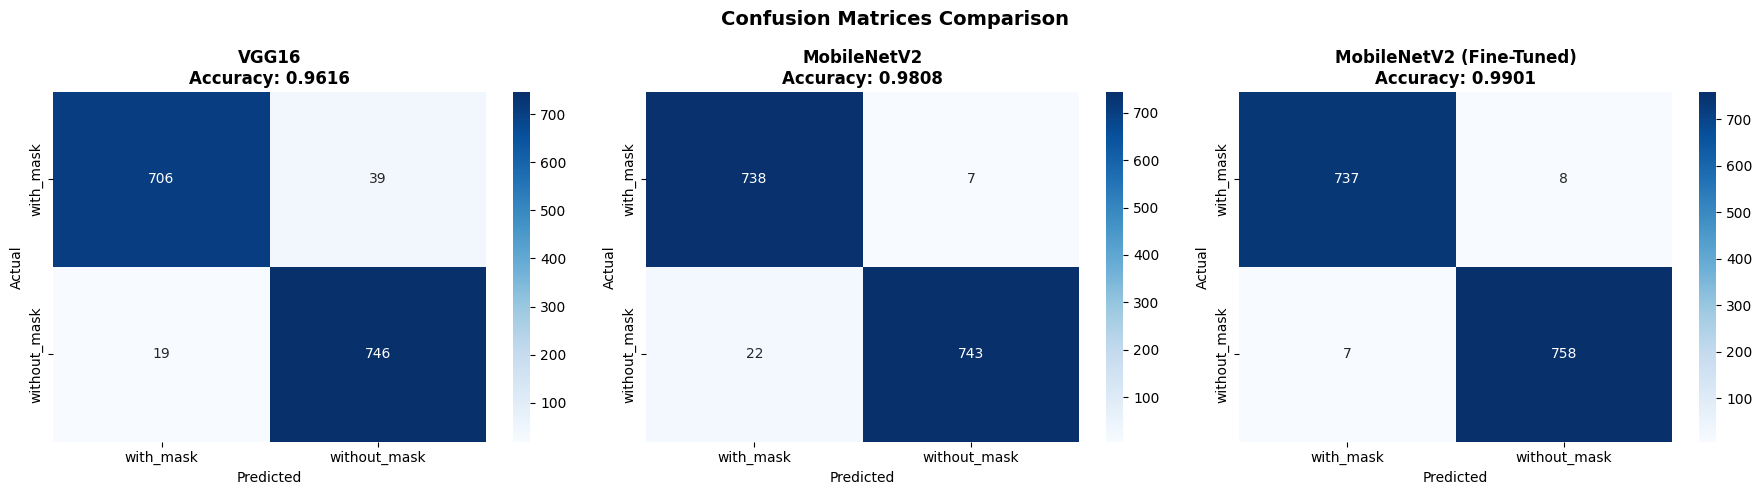

In [24]:
# Plot confusion matrices
if train_dir:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    class_names = list(test_generator.class_indices.keys())
    
    for idx, (name, res) in enumerate(results.items()):
        sns.heatmap(res['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=axes[idx])
        axes[idx].set_title(f"{res['name']}\nAccuracy: {res['accuracy']:.4f}", fontweight='bold')
        axes[idx].set_ylabel('Actual')
        axes[idx].set_xlabel('Predicted')
    
    plt.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [25]:
# Discussion of metrics and model selection
print("METRICS DISCUSSION FOR FACE MASK DETECTION")
print("="*60)
print("""
IMPORTANT METRICS FOR THIS TASK:

1. RECALL for 'Without Mask' class - CRITICAL
   - Missing someone without a mask (False Negative) is dangerous
   - In safety applications, we must catch all violations
   
2. PRECISION for 'Without Mask' class
   - False alarms (predicting no mask when mask is worn) cause inconvenience
   - Balance needed based on deployment context

3. OVERALL ACCURACY
   - Good general measure but can be misleading with class imbalance

MODEL SELECTION CONSIDERATIONS:

- VGG16: Higher accuracy potential but slower, more memory
- MobileNetV2: Faster, lighter, good for real-time applications
- Fine-tuning: Can improve accuracy but requires careful learning rate

HYPERPARAMETER EFFECTS:

- Learning Rate: Lower rates (0.0001) work better for fine-tuning
- Batch Size: Larger batches provide more stable gradients
- Data Augmentation: Critical for preventing overfitting on small datasets
- Dropout: Higher rates (0.5) help with transfer learning
""")

METRICS DISCUSSION FOR FACE MASK DETECTION

IMPORTANT METRICS FOR THIS TASK:

1. RECALL for 'Without Mask' class - CRITICAL
   - Missing someone without a mask (False Negative) is dangerous
   - In safety applications, we must catch all violations
   
2. PRECISION for 'Without Mask' class
   - False alarms (predicting no mask when mask is worn) cause inconvenience
   - Balance needed based on deployment context

3. OVERALL ACCURACY
   - Good general measure but can be misleading with class imbalance

MODEL SELECTION CONSIDERATIONS:

- VGG16: Higher accuracy potential but slower, more memory
- MobileNetV2: Faster, lighter, good for real-time applications
- Fine-tuning: Can improve accuracy but requires careful learning rate

HYPERPARAMETER EFFECTS:

- Learning Rate: Lower rates (0.0001) work better for fine-tuning
- Batch Size: Larger batches provide more stable gradients
- Data Augmentation: Critical for preventing overfitting on small datasets
- Dropout: Higher rates (0.5) help with t

---
# 6. Visualization and Reporting (Rubric Task 5: 8 pts)

**Visualizations:**
1. Training history curves
2. Sample predictions with confidence scores
3. Model comparison charts
4. Final summary report

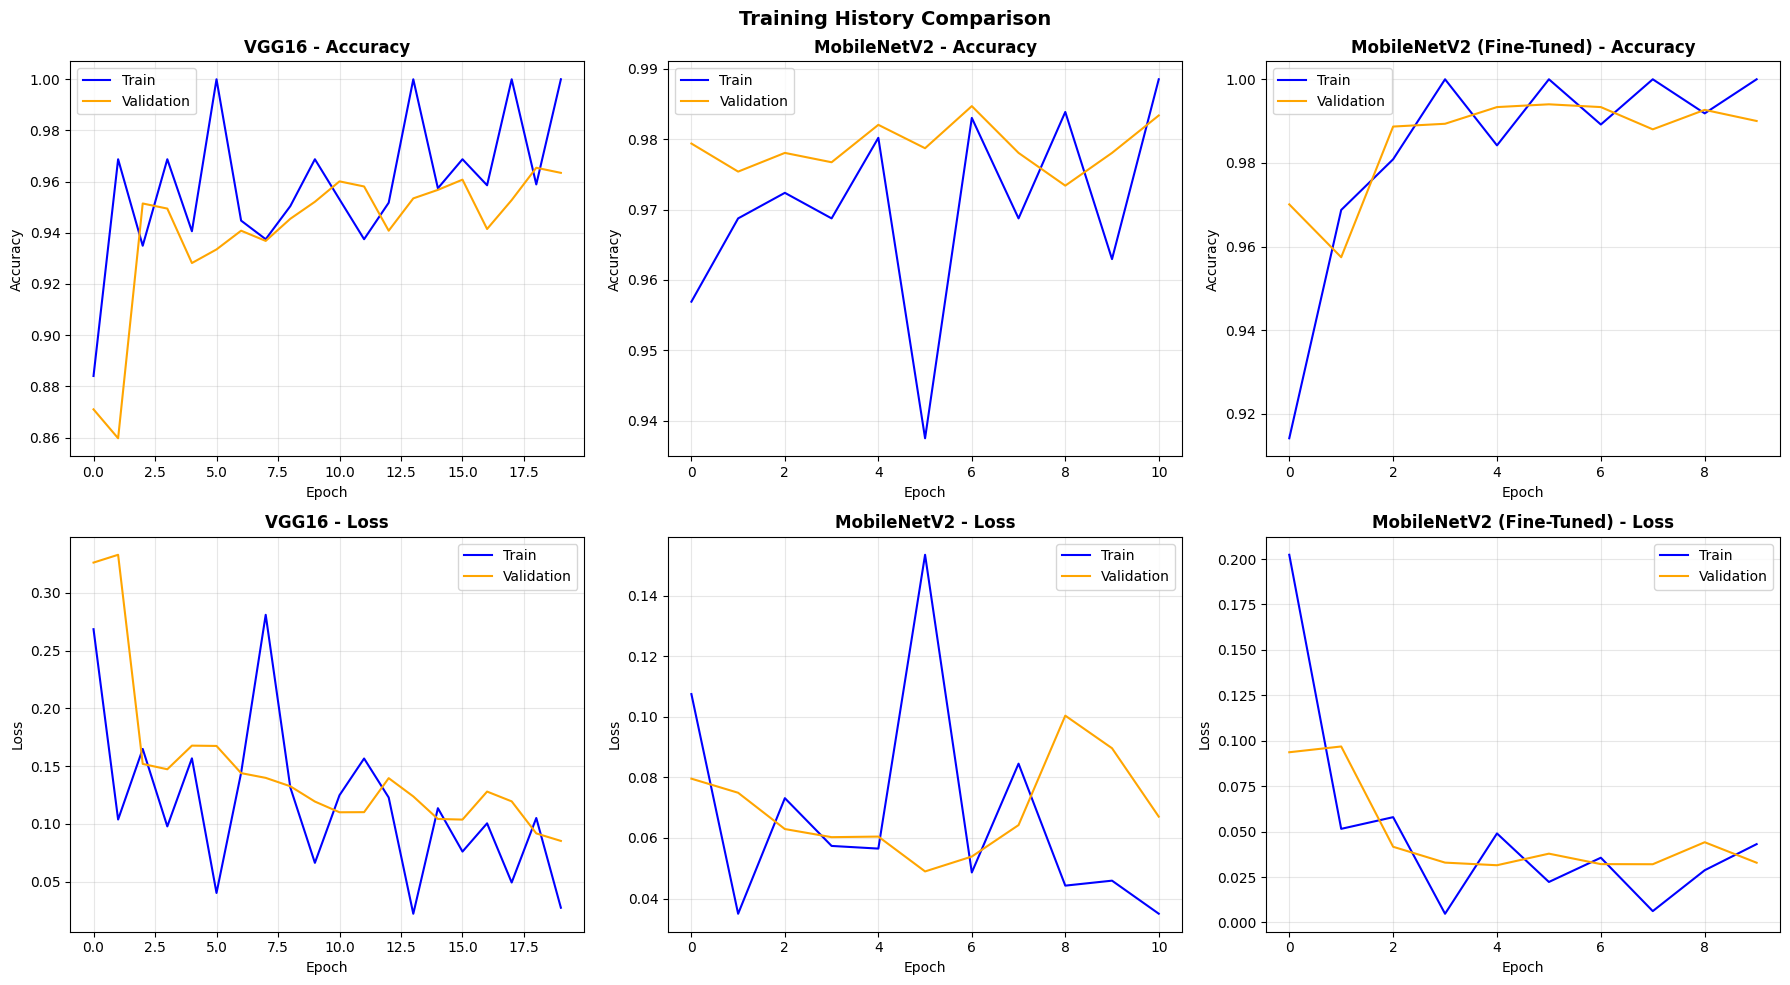

In [26]:
# Plot training histories
def plot_training_history(histories, names):
    """Plot training histories for multiple models."""
    fig, axes = plt.subplots(2, len(histories), figsize=(6*len(histories), 10))
    
    if len(histories) == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, (history, name) in enumerate(zip(histories, names)):
        # Accuracy
        axes[0, idx].plot(history.history['accuracy'], label='Train', color='blue')
        axes[0, idx].plot(history.history['val_accuracy'], label='Validation', color='orange')
        axes[0, idx].set_title(f'{name} - Accuracy', fontweight='bold')
        axes[0, idx].set_xlabel('Epoch')
        axes[0, idx].set_ylabel('Accuracy')
        axes[0, idx].legend()
        axes[0, idx].grid(True, alpha=0.3)
        
        # Loss
        axes[1, idx].plot(history.history['loss'], label='Train', color='blue')
        axes[1, idx].plot(history.history['val_loss'], label='Validation', color='orange')
        axes[1, idx].set_title(f'{name} - Loss', fontweight='bold')
        axes[1, idx].set_xlabel('Epoch')
        axes[1, idx].set_ylabel('Loss')
        axes[1, idx].legend()
        axes[1, idx].grid(True, alpha=0.3)
    
    plt.suptitle('Training History Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

if train_dir:
    plot_training_history(
        [vgg16_history, mobilenet_history, mobilenet_ft_history],
        ['VGG16', 'MobileNetV2', 'MobileNetV2 (Fine-Tuned)']
    )

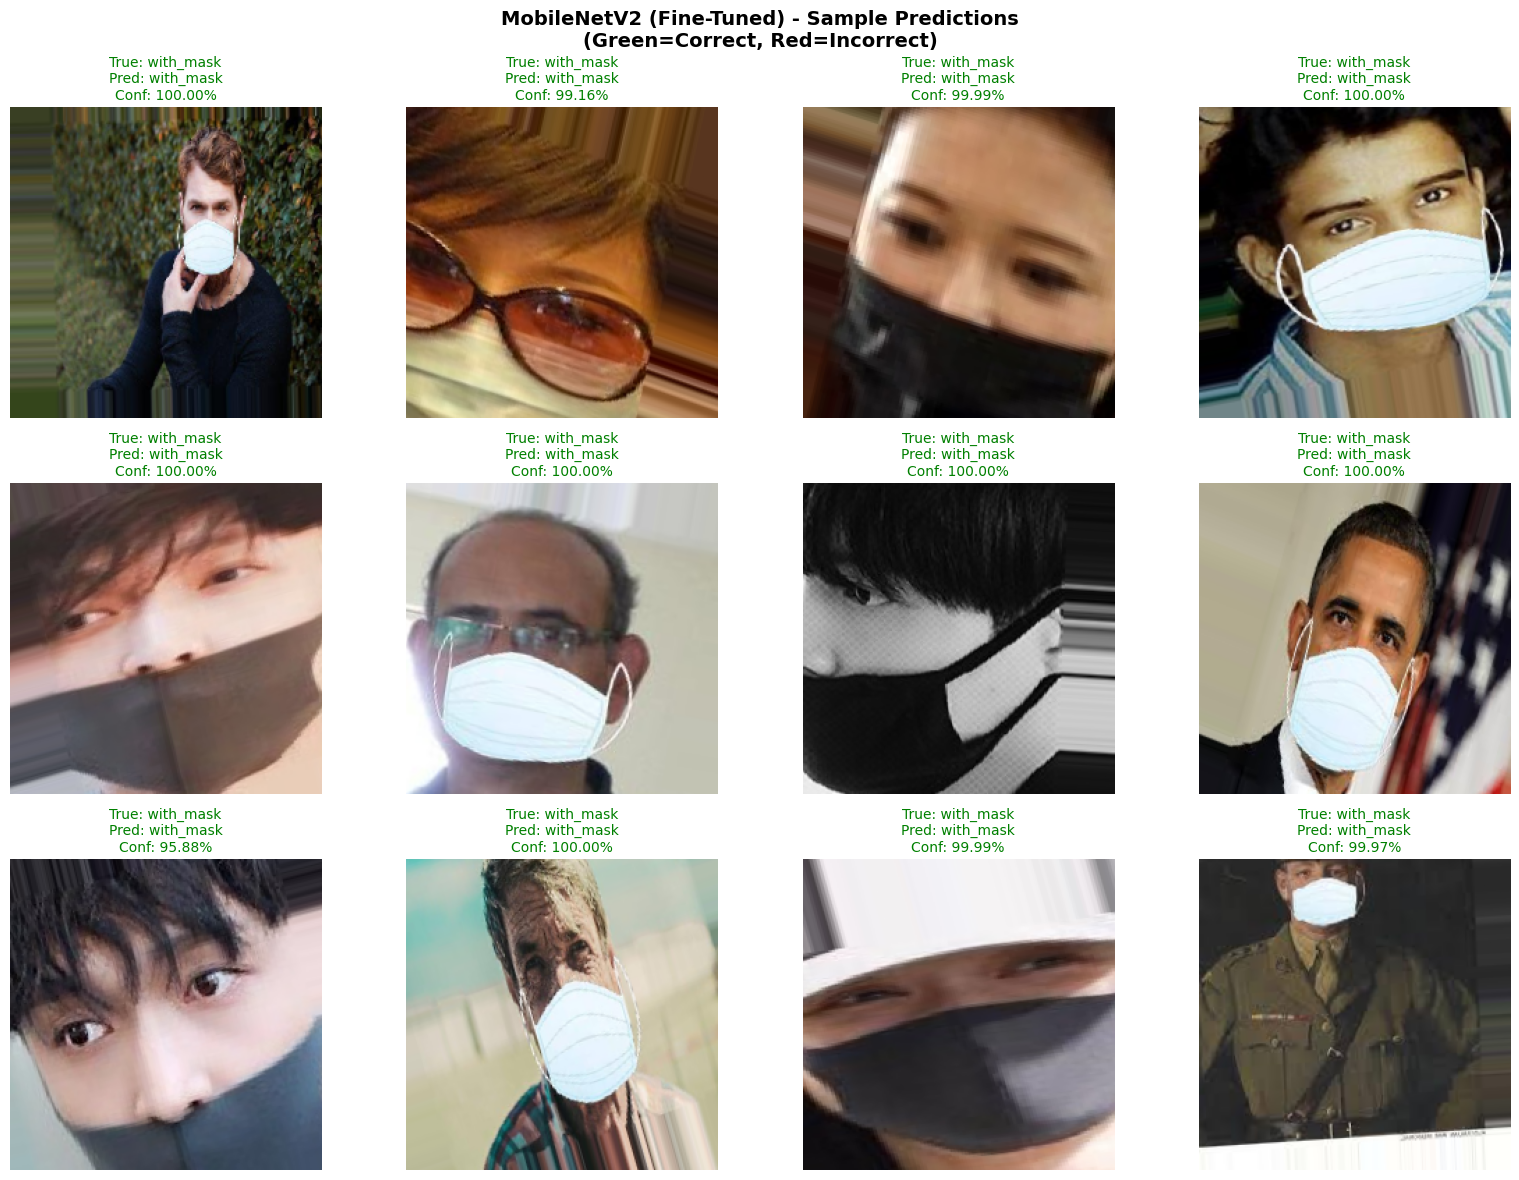

In [27]:
# Visualize sample predictions with confidence scores
def visualize_predictions(model, generator, model_name, n_samples=12):
    """Visualize predictions with confidence scores."""
    generator.reset()
    class_names = list(generator.class_indices.keys())
    
    # Get a batch of images
    images, labels = next(generator)
    predictions = model.predict(images[:n_samples], verbose=0)
    
    # Plot
    n_cols = 4
    n_rows = (n_samples + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten()
    
    for i in range(n_samples):
        ax = axes[i]
        ax.imshow(images[i])
        
        true_label = class_names[int(labels[i])]
        pred_prob = predictions[i][0]
        pred_label = class_names[1] if pred_prob > 0.5 else class_names[0]
        confidence = pred_prob if pred_prob > 0.5 else 1 - pred_prob
        
        # Color based on correct/incorrect
        color = 'green' if true_label == pred_label else 'red'
        
        ax.set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2%}',
                    color=color, fontsize=10)
        ax.axis('off')
    
    # Hide unused subplots
    for i in range(n_samples, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'{model_name} - Sample Predictions\n(Green=Correct, Red=Incorrect)',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

if train_dir and best_model:
    # Use the best model for visualization
    if 'VGG16' in best_model:
        visualize_predictions(vgg16_model, test_generator, 'VGG16')
    elif 'FineTune' in best_model:
        visualize_predictions(mobilenet_ft_model, test_generator, 'MobileNetV2 (Fine-Tuned)')
    else:
        visualize_predictions(mobilenet_model, test_generator, 'MobileNetV2')

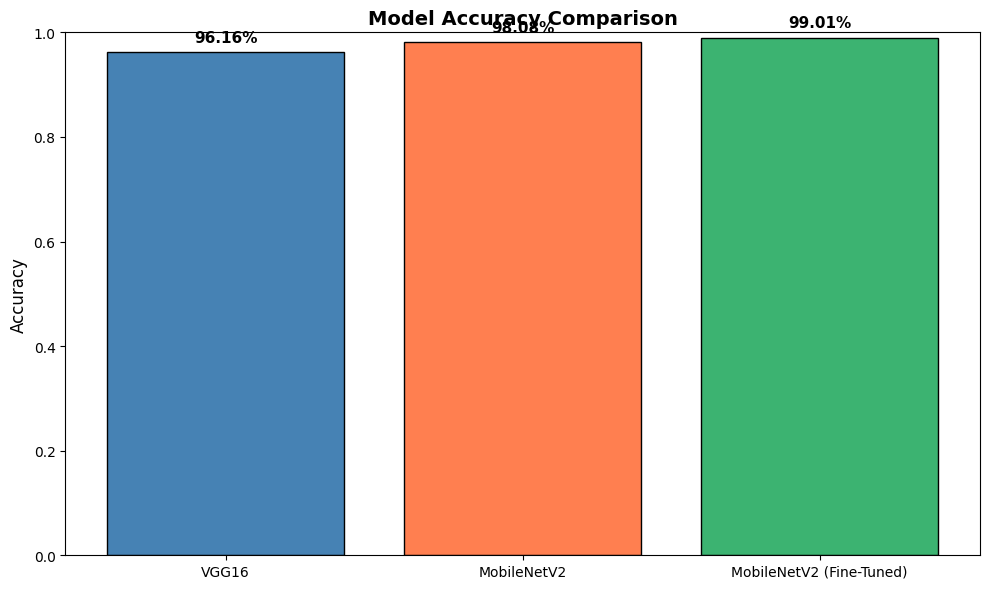

In [28]:
# Model accuracy comparison bar chart
if train_dir:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    model_names = [res['name'] for res in results.values()]
    accuracies = [res['accuracy'] for res in results.values()]
    
    colors = ['steelblue', 'coral', 'mediumseagreen']
    bars = ax.bar(model_names, accuracies, color=colors, edgecolor='black')
    
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    
    # Add value labels
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
               f'{acc:.2%}', ha='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

In [29]:
# Final Summary Report
print("="*70)
print("                    FINAL SUMMARY REPORT")
print("="*70)
print("""
PROJECT: Face Mask Detection using Transfer Learning
""")

print("1. DATA PREPROCESSING")
print("-"*70)
print(f"   - Image Size: {IMG_HEIGHT}x{IMG_WIDTH} pixels")
print(f"   - Normalization: Pixel values scaled to [0, 1]")
print(f"   - Augmentation: Rotation, shift, flip, zoom applied")
print(f"   - Train/Val Split: 80%/20%")

print("\n2. MODELS BUILT")
print("-"*70)
print("   - VGG16 (Feature Extraction)")
print("   - MobileNetV2 (Feature Extraction)")
print("   - MobileNetV2 (Fine-Tuned)")
print("   - All models use: GlobalAveragePooling, Dense layers, Dropout, BatchNorm")

print("\n3. TRAINING CONFIGURATION")
print("-"*70)
print(f"   - Epochs: {EPOCHS}")
print(f"   - Batch Size: {BATCH_SIZE}")
print("   - Optimizer: Adam")
print("   - Loss: Binary Crossentropy")
print("   - Callbacks: EarlyStopping, ReduceLROnPlateau")

print("\n4. RESULTS")
print("-"*70)
if train_dir:
    for name, res in results.items():
        print(f"   - {res['name']}: {res['accuracy']:.2%} accuracy")
    print(f"\n   BEST MODEL: {best_model}")

print("\n5. KEY FINDINGS")
print("-"*70)
print("""
   - Transfer learning significantly speeds up training
   - Pre-trained ImageNet features transfer well to face detection
   - Fine-tuning can improve accuracy with careful learning rate selection
   - MobileNetV2 offers good accuracy with smaller model size
   - Data augmentation is critical for preventing overfitting
""")

print("\n6. RECOMMENDATIONS")
print("-"*70)
print("""
   - For real-time applications, use MobileNetV2 (faster inference)
   - For highest accuracy, use fine-tuned model with more epochs
   - Consider ensemble methods for production deployment
   - Collect more diverse data for better generalization
""")
print("="*70)

                    FINAL SUMMARY REPORT

PROJECT: Face Mask Detection using Transfer Learning

1. DATA PREPROCESSING
----------------------------------------------------------------------
   - Image Size: 224x224 pixels
   - Normalization: Pixel values scaled to [0, 1]
   - Augmentation: Rotation, shift, flip, zoom applied
   - Train/Val Split: 80%/20%

2. MODELS BUILT
----------------------------------------------------------------------
   - VGG16 (Feature Extraction)
   - MobileNetV2 (Feature Extraction)
   - MobileNetV2 (Fine-Tuned)
   - All models use: GlobalAveragePooling, Dense layers, Dropout, BatchNorm

3. TRAINING CONFIGURATION
----------------------------------------------------------------------
   - Epochs: 20
   - Batch Size: 32
   - Optimizer: Adam
   - Loss: Binary Crossentropy
   - Callbacks: EarlyStopping, ReduceLROnPlateau

4. RESULTS
----------------------------------------------------------------------
   - VGG16: 96.16% accuracy
   - MobileNetV2: 98.08% accuracy
